# Lezione 2 — Esplorare i dati con pandas

Useremo **pandas** per caricare e analizzare i tweet reali prima di costruire qualsiasi modello ML.

**Dataset:** 8 file `.txt`, uno per emozione — 60.000 tweet ciascuno:
`anger | anticipation | disgust | fear | joy | sadness | surprise | trust`

> **Regola del ML:** prima di costruire un modello, devi *conoscere* i tuoi dati.

---

## Cos'è pandas e cos'è un DataFrame?

**pandas** è la libreria Python più usata per lavorare con dati tabellari (righe e colonne), simili a un foglio Excel.

### DataFrame
Un **DataFrame** è la struttura dati principale di pandas. Immagina una tabella:

| testo                        | emozione |
|------------------------------|----------|
| "I'm so angry right now!"    | anger    |
| "This is amazing, I love it" | joy      |
| "I'm scared of the dark"     | fear     |

- Ogni **riga** è un'osservazione (nel nostro caso, un tweet)
- Ogni **colonna** è una variabile (nel nostro caso: il testo del tweet e la sua emozione)
- Ogni colonna ha un **nome** e un **tipo** (testo, numero, data…)

### Perché pandas?
Con poche righe di codice possiamo:
- caricare migliaia di righe da un file
- filtrare, ordinare, raggruppare i dati
- calcolare statistiche
- creare grafici

> **Analogia:** Se Python è il coltellino svizzero della programmazione, pandas è il coltellino svizzero per i dati.


In [1]:
# Solo su Google Colab — decommentare la riga sotto
#%pip install pandas matplotlib seaborn

### Le librerie che useremo

```python
import pandas as pd        # gestione dati (DataFrames)
import matplotlib.pyplot as plt  # grafici di base
import seaborn as sns      # grafici statistici più belli
import os                  # operazioni sul filesystem (percorsi, file)
```

- **`import ... as ...`** → importa la libreria con un alias abbreviato (convenzione universale: `pd`, `plt`, `sns`)
- **`os`** è una libreria standard di Python che ci permette di costruire percorsi ai file in modo che funzionino su Windows, Mac e Linux


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print('Librerie caricate correttamente!')

Librerie caricate correttamente!


## 1. Caricare un singolo file

Iniziamo con i tweet di **rabbia** (`anger`).

Il file **non ha intestazione** (header): ogni riga e' semplicemente un tweet grezzo.
Dobbiamo specificare noi il nome della colonna.

In [3]:
DATASET_PATH = '../DATASET'

percorso = os.path.join(DATASET_PATH, 'dataset_dt_anger_60k.txt')

with open(percorso, 'r', encoding='utf-8', errors='replace') as f:
    righe = [riga.strip() for riga in f if riga.strip()]

df_anger = pd.DataFrame({'testo': righe})

print(f'Tweet caricati: {len(df_anger)}')
df_anger.head()

FileNotFoundError: [Errno 2] No such file or directory: '../DATASET\\dataset_dt_anger_60k.txt'

### Cosa fa questo codice — passo per passo

```python
# 1. Costruisce il percorso al file in modo sicuro
percorso = os.path.join(DATASET_PATH, 'dataset_dt_anger_60k.txt')

# 2. Apre il file e legge le righe non vuote
with open(percorso, 'r', encoding='utf-8', errors='replace') as f:
    righe = [riga.strip() for riga in f if riga.strip()]
```

**`open(...)`** apre un file:
- `'r'` = sola lettura (*read*)
- `encoding='utf-8'` = come interpretare i caratteri speciali (emoji, accenti...)
- `errors='replace'` = se un carattere è illeggibile, sostituiscilo invece di andare in errore

**List comprehension** `[... for riga in f if ...]` → modo compatto di costruire una lista in Python:
```python
# Equivalente "lungo":
righe = []
for riga in f:
    if riga.strip():        # salta le righe vuote
        righe.append(riga.strip())  # rimuove spazi/newline a inizio e fine
```

**`pd.DataFrame({'testo': righe})`** → crea un DataFrame con una sola colonna chiamata `testo`, dove ogni elemento della lista diventa una riga.


In [ ]:
# Il file non contiene la label — il label e' nel NOME del file
# Dobbiamo aggiungerla manualmente come nuova colonna
df_anger['emozione'] = 'anger'

df_anger.head()

,testo,emozione
0,USERNAME f u what's that spell ? fired up ? no...,anger
1,now all of you roll tide bandwagon fans will h...,anger
2,"this weeken d: tcu football , next weeken d: m...",anger
3,i wish i could go drive myself to wingstop but...,anger
4,must rea d: gail collins on hillary's next mov...,anger


## 2. Caricare tutte le 8 emozioni in un unico DataFrame

Ripetiamo l'operazione per tutte le emozioni usando un ciclo `for`,
poi uniamo tutti i DataFrame in uno solo con `pd.concat`.

### Concetti chiave: ciclo `for`, liste e `pd.concat`

**Ciclo `for` con lista di stringhe:**
```python
for em in ['anger', 'joy', 'fear']:
    print(em)
# → anger
# → joy
# → fear
```

**`dfs.append(df_tmp)`** → aggiunge un DataFrame alla lista `dfs` ad ogni iterazione.
Alla fine del ciclo `dfs` contiene 8 DataFrame separati, uno per emozione.

**`pd.concat(dfs, ignore_index=True)`** → incolla verticalmente tutti i DataFrame della lista:

```
[df_anger]          testo | emozione
[df_joy]     →      ...   | anger
[df_fear]           ...   | joy
  ...                ...   | fear
```

`ignore_index=True` → ricalcola l'indice di riga da 0, invece di tenere gli indici originali (che andrebbero da 0 a 59999 per ogni pezzo).


In [ ]:
emozioni = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

dfs = []
for em in emozioni:
    percorso = os.path.join(DATASET_PATH, f'dataset_dt_{em}_60k.txt')
    with open(percorso, 'r', encoding='utf-8', errors='replace') as f:
        righe = [riga.strip() for riga in f if riga.strip()]
        df_tmp = pd.DataFrame({'testo': righe})
        df_tmp['emozione'] = em
        dfs.append(df_tmp)
        print(f' {em:15s}: {len(df_tmp)} tweet')      

# Uniamo tutti i DataFrame in uno
df = pd.concat(dfs, ignore_index=True)
print(f'\nDataFrame totale: {df.shape[0]} righe, {df.shape[1]} colonne')
df.head()

 anger          : 60000 tweet
 anticipation   : 60000 tweet
 disgust        : 60000 tweet
 fear           : 60000 tweet
 joy            : 60000 tweet
 sadness        : 60000 tweet
 surprise       : 60000 tweet
 trust          : 60000 tweet

DataFrame totale: 480000 righe, 2 colonne


,testo,emozione
0,USERNAME f u what's that spell ? fired up ? no...,anger
1,now all of you roll tide bandwagon fans will h...,anger
2,"this weeken d: tcu football , next weeken d: m...",anger
3,i wish i could go drive myself to wingstop but...,anger
4,must rea d: gail collins on hillary's next mov...,anger


## 3. Esplorare il dataset

> Prima regola del ML: **conosci i tuoi dati** prima di costruire qualsiasi modello.

### Operazioni base su un DataFrame

| Operazione | Codice | Risultato |
|---|---|---|
| Dimensioni (righe, colonne) | `df.shape` | `(480000, 2)` |
| Prime N righe | `df.head(5)` | tabella con 5 righe |
| Tipi delle colonne | `df.dtypes` | `testo: object, emozione: object` |
| Contare valori unici | `df['emozione'].value_counts()` | quanti tweet per emozione |
| Accedere a una colonna | `df['testo']` | la serie con tutti i testi |

**`df.shape`** restituisce una coppia `(n_righe, n_colonne)` — come le dimensioni di una matrice.

**`df['nome_colonna']`** → seleziona una singola colonna; il risultato si chiama **Series** (una lista con un indice).


In [ ]:
# Dimensioni generali
print('Dimensioni del DataFrame:', df.shape)
print('\nTipi di dato per colonna:')
print(df.dtypes)
print('\nPrime 10 righe:')
df.head(10)

NameError: name 'df' is not defined

In [ ]:
# Distribuzione delle classi
# Importante: le classi sono bilanciate? Un dataset sbilanciato crea problemi al modello
print('Tweet per emozione:')
print(df['emozione'].value_counts())

Tweet per emozione:
emozione
anger           60000
anticipation    60000
disgust         60000
fear            60000
joy             60000
sadness         60000
surprise        60000
trust           60000
Name: count, dtype: int64


### Creare grafici con matplotlib (`plt`)

**matplotlib** è la libreria di riferimento per i grafici in Python. La usiamo sempre tramite il sottomodulo `pyplot`, importato come `plt`.

La struttura tipica di un grafico è sempre la stessa:

```python
plt.figure(figsize=(larghezza, altezza))  # 1. crea una "tela" vuota (in pollici)

# 2. disegna qualcosa sulla tela
df['colonna'].plot(kind='bar')            #    grafico a barre
# oppure plt.plot(x, y)                  #    linea
# oppure plt.hist(dati)                  #    istogramma

plt.title('Titolo del grafico')           # 3. aggiungi etichette
plt.xlabel('Asse X')
plt.ylabel('Asse Y')
plt.xticks(rotation=45)                   #    ruota le etichette sull'asse X di 45°

plt.tight_layout()                        # 4. sistema automaticamente i margini
plt.show()                                # 5. mostra il grafico
```

**`figsize=(10, 5)`** → larghezza 10, altezza 5 (in "pollici" virtuali). Valori più grandi = grafico più grande.

**`plt.xticks(rotation=45)`** → ruota le etichette sull'asse X di 45° per evitare che si sovrappongano quando sono lunghe.

**`plt.tight_layout()`** → aggiusta automaticamente i margini affinché titoli ed etichette non vengano tagliati.


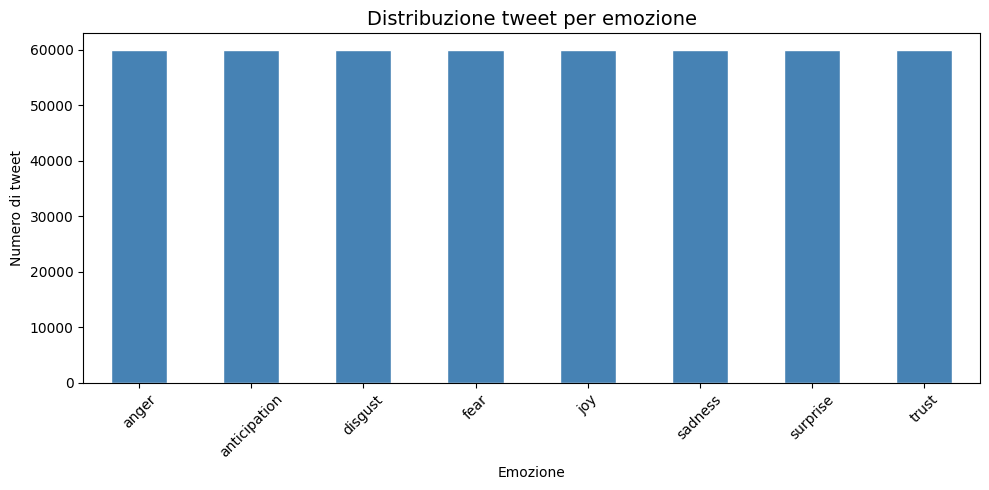

In [ ]:
# Grafico a barre della distribuzione
plt.figure(figsize=(10, 5))
df['emozione'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribuzione tweet per emozione', fontsize=14)
plt.xlabel('Emozione')
plt.ylabel('Numero di tweet')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Qualita' dei dati: valori mancanti e duplicati

> Un modello addestrato su dati sporchi produce risultati sporchi.
> Pulire i dati e' uno dei passi piu' importanti — e piu' sottovalutati — del ML.

### Cos'è un valore mancante (NaN)?

**NaN** (*Not a Number*) è il modo di pandas di rappresentare un dato assente o non leggibile.
È diverso da una stringa vuota `""` — è proprio l'assenza di un valore.

```python
df.isnull().sum()   # conta i NaN per ogni colonna
df.dropna()         # rimuove le righe che contengono almeno un NaN
```

### Cos'è un duplicato?

Un duplicato è una riga identica che appare più volte nel dataset.
Può succedere perché lo stesso tweet è stato raccolto più volte dalla fonte dati.

```python
df.duplicated(subset=['testo']).sum()   # quante righe sono uguali nella colonna 'testo'
df.drop_duplicates(subset=['testo'])    # tieni solo la prima occorrenza
```

> **Perché è importante?** Se lo stesso tweet compare 10 volte nel training set, il modello impara a "memorizzarlo" invece di generalizzare — un errore chiamato **overfitting**.


In [ ]:
# Valori mancanti (NaN)
print('Valori mancanti per colonna:')
print(df.isnull().sum())

df = df.dropna(subset=['testo'])
print(f'\nRighe dopo rimozione NaN: {len(df)}')

Valori mancanti per colonna:
testo       0
emozione    0
dtype: int64

Righe dopo rimozione NaN: 480000


In [ ]:
# Duplicati: tweet identici contati due volte distorcono il training
n_dup = df.duplicated(subset=['testo']).sum()
print(f'Righe duplicate: {n_dup}')

df = df.drop_duplicates(subset=['testo'])
print(f'Righe dopo rimozione duplicati: {len(df)}')

Righe duplicate: 73181
Righe dopo rimozione duplicati: 406819


## 5. Lunghezza dei tweet

Osserviamo se le diverse emozioni tendono a produrre tweet piu' lunghi o piu' corti.
Questa e' un'analisi esplorativa — potrebbe rivelare pattern interessanti.

### Operazioni sulle stringhe con `.str`

pandas permette di applicare operazioni sulle stringhe a tutta una colonna in una sola riga, usando il prefisso **`.str`**:

```python
df['testo'].str.len()        # lunghezza in caratteri di ogni testo
df['testo'].str.upper()      # tutto maiuscolo
df['testo'].str.split()      # divide ogni testo in una lista di parole
df['testo'].str.contains('!') # True/False: contiene il punto esclamativo?
```

È molto più veloce di un ciclo `for` perché pandas lavora internamente in modo ottimizzato.

### `groupby` — raggruppare i dati

```python
df.groupby('emozione')['lunghezza'].describe()
```
Funziona così:
1. `groupby('emozione')` → divide il DataFrame in 8 gruppi (uno per emozione)
2. `['lunghezza']` → seleziona la colonna lunghezza in ogni gruppo
3. `.describe()` → calcola min, max, media, mediana... per ogni gruppo

> Equivalente a: *"per ogni emozione, dimmi le statistiche sulla lunghezza"*


In [ ]:
# Aggiungiamo una colonna con la lunghezza in caratteri
df['lunghezza'] = df['testo'].str.len()

print('Statistiche lunghezza tweet per emozione:')
print(df.groupby('emozione')['lunghezza'].describe().round(1))

Statistiche lunghezza tweet per emozione:
                count  mean   std   min   25%   50%   75%    max
emozione                                                        
anger         59750.0  78.3  28.6  21.0  55.0  72.0  98.0  266.0
anticipation  59714.0  78.1  27.3  24.0  56.0  72.0  96.0  262.0
disgust       31744.0  75.3  27.1  21.0  54.0  69.0  92.0  242.0
fear          42945.0  74.6  27.1  19.0  53.0  68.0  91.0  242.0
joy           57595.0  76.0  26.9  19.0  55.0  70.0  93.0  248.0
sadness       54202.0  76.0  27.4  21.0  54.0  69.0  93.0  267.0
surprise      57009.0  77.8  27.5  20.0  56.0  72.0  96.0  224.0
trust         43860.0  75.8  27.7  19.0  54.0  69.0  94.0  254.0


### Boxplot con seaborn (`sns`)

Un **boxplot** (diagramma a scatola) mostra la distribuzione di valori numerici in modo compatto:

```
        ┌───┬───┐
  ──────┤   │   ├──────  ←  "baffi" (whiskers): min/max escludendo outlier
        └───┴───┘
          ↑   ↑
       Q1  Q3       ←  la scatola copre il 50% centrale dei dati
          ↑
         Q2 = mediana
```

- **Scatola** → contiene il 50% centrale dei valori (dal 25° al 75° percentile)
- **Linea centrale** → mediana (il valore che sta a metà)
- **Baffi** → si estendono fino ai valori non anomali
- **Punti fuori dai baffi** → **outlier** (valori anomali)

**seaborn** (`sns`) è costruito sopra matplotlib e produce grafici statistici più curati con meno codice:

```python
sns.boxplot(data=df, x='emozione', y='lunghezza', palette='Set2')
```
- `data=df` → il DataFrame da cui leggere i dati
- `x=` → colonna da mettere sull'asse X (categorica)
- `y=` → colonna da mettere sull'asse Y (numerica)
- `palette=` → schema di colori (es. `'Set2'`, `'husl'`, `'Blues'`)

> Anche con seaborn, si usano `plt.title()`, `plt.xlabel()` ecc. per aggiungere etichette — seaborn e matplotlib lavorano insieme.


C:\Users\Manuela\AppData\Local\Temp\ipykernel_5464\3502021330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='emozione', y='lunghezza', palette='Set2')


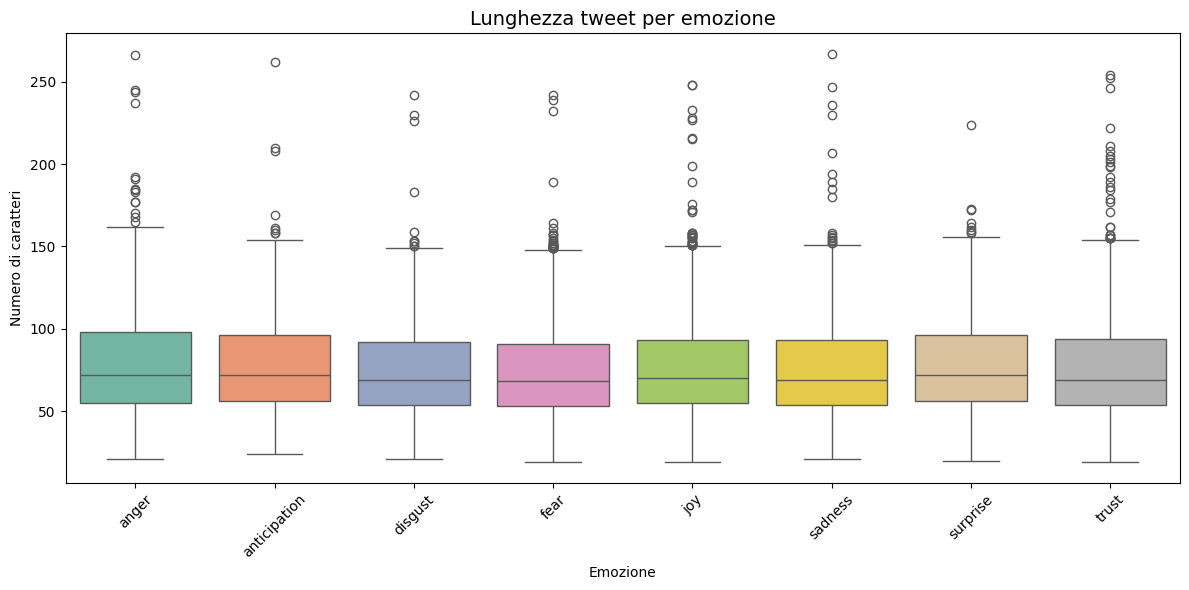

In [ ]:
# Boxplot: visualizziamo la distribuzione della lunghezza per ogni emozione
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='emozione', y='lunghezza', palette='Set2')
plt.title('Lunghezza tweet per emozione', fontsize=14)
plt.xlabel('Emozione')
plt.ylabel('Numero di caratteri')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Campionamento — lavorare velocemente in classe

480.000 tweet richiedono troppo tempo per addestrare un modello in classe.
Selezioniamo **2.000 tweet per emozione** (16.000 totali), mantenendo le classi bilanciate.

> `random_state=42` garantisce che tutti ottengano lo stesso campione — importante per riproducibilita'.

### Campionamento e riproducibilità

**Campionamento** = selezionare un sottoinsieme casuale dei dati.

```python
x.sample(n=2000, random_state=42)
```
- `n=2000` → prendi 2000 righe a caso
- `random_state=42` → "seme" del generatore casuale: con lo stesso numero si ottiene **sempre lo stesso campione** (importante per fare esperimenti riproducibili)

> Il numero 42 non ha nulla di speciale — è una convenzione scherzosa nata da *"Il guida galattica per gli autostoppisti"*. Potete usare qualsiasi numero intero.

**`lambda x: x.sample(...)`** → una funzione anonima (senza nome) applicata a ogni gruppo:
```python
# Equivalente "lungo":
def campiona(x):
    return x.sample(min(len(x), CAMPIONE), random_state=42)

df.groupby('emozione').apply(campiona)
```


In [ ]:
CAMPIONE = 2000

chunks = [
  group.sample(min(len(group), CAMPIONE), random_state=42)
  for _, group in df.groupby('emozione')
]

df_campione = pd.concat(chunks).reset_index(drop=True)
print('Campione finale:')
print(df_campione['emozione'].value_counts())

# Salviamo solo testo e emozione — le altre colonne non servono
df_campione[['testo', 'emozione']].to_csv('dataset_campione.csv', index=False)
print('\nFile salvato: dataset_campione.csv (servira nella Lezione 3)')

Campione finale:
emozione
anger           2000
anticipation    2000
disgust         2000
fear            2000
joy             2000
sadness         2000
surprise        2000
trust           2000
Name: count, dtype: int64

File salvato: dataset_campione.csv  (servira nella Lezione 3)


C:\Users\Manuela\AppData\Local\Temp\ipykernel_5464\308126532.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), CAMPIONE), random_state=42))


---
## Esercizi

1. Quale emozione ha i tweet piu' lunghi in media?
2. Aggiungi una colonna `num_parole` con il numero di parole per tweet.
   *(Suggerimento: `df['testo'].str.split().apply(len)`)*
3. Trova i 5 tweet piu' corti del dataset. Cosa noti?
4. Modifica il campionamento a 3.000 tweet per classe. Quanti tweet totali ottieni?
5. *(Difficile)* Crea un grafico a barre che mostra la lunghezza media per emozione,
   con le barre ordinate dalla piu' corta alla piu' lunga.